In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
insurance_df = pd.read_csv('../01_data/raw_full.csv')

In [3]:
print(insurance_df.shape)
insurance_df.head()

(381109, 12)


,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [4]:
# check var types
insurance_df.dtypes

id                        int64
Gender                      str
Age                       int64
Driving_License           int64
Region_Code             float64
Previously_Insured        int64
Vehicle_Age                 str
Vehicle_Damage              str
Annual_Premium          float64
Policy_Sales_Channel    float64
Vintage                   int64
Response                  int64
dtype: object

In [5]:
#check for missing values
insurance_df.isnull().sum()

id                      0
Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
Response                0
dtype: int64

In [6]:
insurance_df.nunique()

id                      381109
Gender                       2
Age                         66
Driving_License              2
Region_Code                 53
Previously_Insured           2
Vehicle_Age                  3
Vehicle_Damage               2
Annual_Premium           48838
Policy_Sales_Channel       155
Vintage                    290
Response                     2
dtype: int64

In [7]:
insurance_df['Annual_Premium_log'] = np.log1p(insurance_df['Annual_Premium'])

In [8]:
#finding Q1 and Q3
Q3,Q1 = np.percentile(insurance_df['Annual_Premium'], [75,25])
IQR = Q3-Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

insurance_df_clean = insurance_df[(insurance_df['Annual_Premium'] >= lower_bound) & (insurance_df['Annual_Premium'] <= upper_bound)]
len(insurance_df_clean)

370789

# Data Exploration

## Target Variable

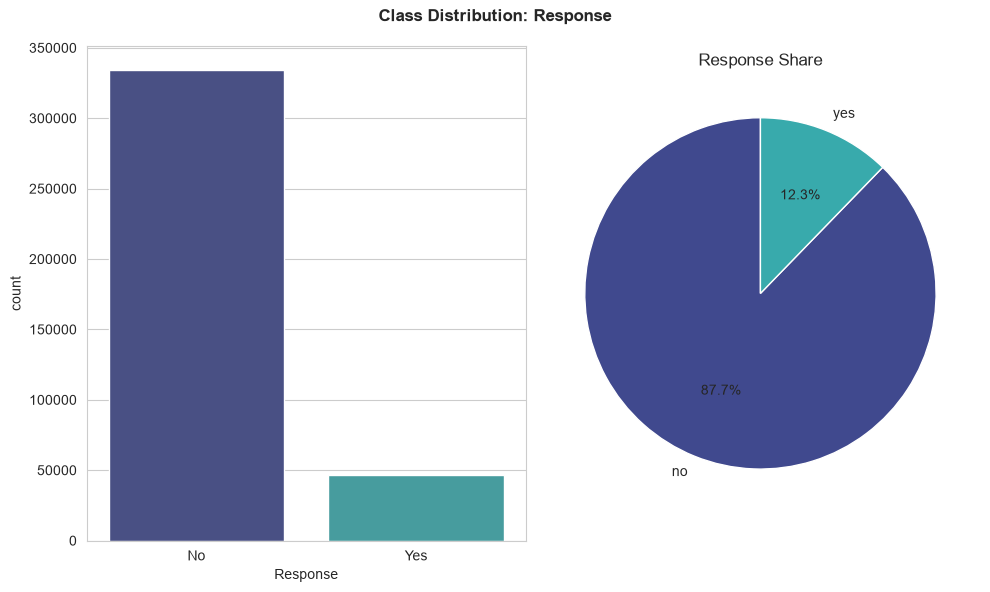

In [9]:
sns.set_style('whitegrid')

# Target variable distribution visualization
fig, axes = plt.subplots(1,2, figsize = (10,6))

sns.countplot(data = insurance_df, x = 'Response', hue = 'Response', palette = 'mako',legend = False, ax = axes[0])
axes[0].set_xticks([0,1]) #using set_xticks so data is not mislabeled
axes[0].set_xticklabels(['No','Yes'])
axes[1].pie(insurance_df['Response'].value_counts(),
            labels = ['no','yes'],
            autopct='%1.1f%%',
            startangle = 90,
            colors = sns.color_palette('mako',2)
)
plt.title('Response Share')
plt.suptitle('Class Distribution: Response', fontweight = 'bold')
plt.tight_layout()
plt.show()

**The target variable Response is highly imbalanced, with 87.7% of customers saying no and only 12.3% saying yes. For modeling, this means that accuracy alone will be a misleading metric, so metrics such as precision, sensitivity, and F-scores should be prioritized. Additionally, resampling methods might be needed to handle class imbalance.**

In [10]:
response_counts = insurance_df['Response'].value_counts()
response_counts.reset_index()

,Response,count
0,0,334399
1,1,46710


### Binary Variables Distribution

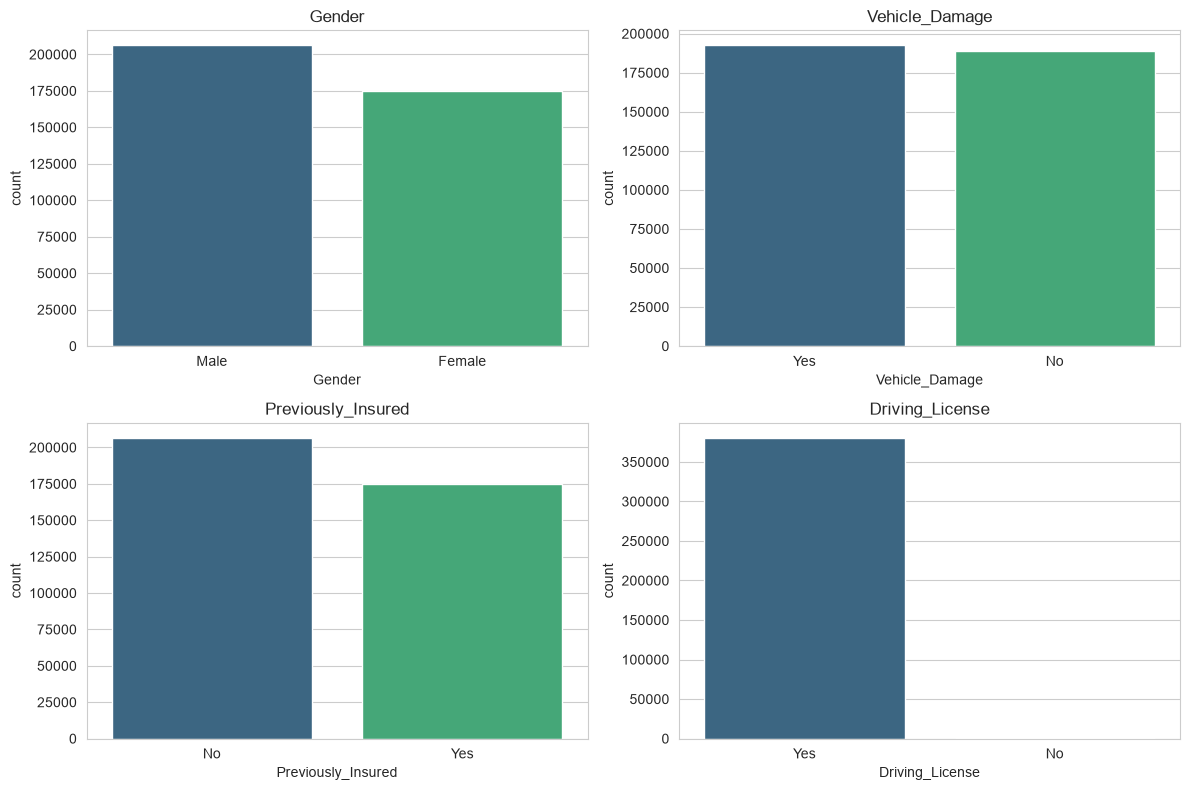

In [11]:
cols = ['Gender', 'Vehicle_Damage', 'Previously_Insured', 'Driving_License']
label_map = {0: 'No', 1:'Yes'}

fig, axes = plt.subplots( 2,2, figsize = (12,8))
axes = axes.flatten() # turns 2x2 grid into flat list for indexing ? 

for i, col in enumerate(cols):
    if insurance_df[col].dtype in ['int64','int32']:
        plot_data = insurance_df[col].map(label_map)
    else:
        plot_data = insurance_df[col]
        
    sns.countplot(x = plot_data, hue=plot_data, palette='viridis', legend = False,ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

**Most categorical features like `Gender`, `Vehicle_Damage`, and `Previously_Insured` show a relatively balanced distribution across their categories. However, Driving_License is highly imbalanced since most customers have a license, which means that it may have little predictive value and could be excluded from the model.** 

### Numerical Variables 

In [ ]:
cols = ['Age', 'Annual_Premium', 'Vintage', 'Annual_Premium_log']
fig, axes = plt.subplots(2,2, figsize = (14,6))
axes = axes.flatten()
for i, col in enumerate(cols):
    plot_data = insurance_df[col]
    sns.histplot(x = plot_data, ax=axes[i], color='grey')
    axes[i].axvline(insurance_df[col].mean(), color ='red',linestyle='--',  linewidth =1.5, label= 'Mean')
    axes[i].axvline(insurance_df[col].median(), color ='blue',linestyle='--',  linewidth =1.5, label= 'Median')
    axes[i].set_title(col)
    axes[i].legend()

plt.tight_layout()
plt.show()

**Age shows a bimodal, right-skewed distribution, suggesting different customer segments, while Vintage has a uniform distribution with no skewness. Annual_Premium is extremely right-skewed, with a long tail of high outliers. Applying a log transform helps with visualization and may also help certain models, such as kNNs or SVMs.**

In [ ]:
cols = ['Age', 'Annual_Premium', 'Vintage', 'Annual_Premium_log']
colors = ['mediumaquamarine', 'red', 'salmon', 'yellow']

# palette = sns.color_palette('mako_r', len(cols))
fig, axes = plt.subplots(2,2, figsize = (12,8))
axes = axes.flatten()
for i, col in enumerate(cols):
    plot_data = insurance_df[col]
    sns.boxplot(x = plot_data, ax = axes[i], color = colors[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis = 'x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize = (8,6))
order = ['< 1 Year', '1-2 Year','> 2 Years']
sns.countplot(data = insurance_df, x='Vehicle_Age', hue='Vehicle_Age', palette = 'mako', order=order, ax=ax)
plt.title('Vehicle Age', fontweight = 'bold')
plt.show()

In [ ]:
top_regions = insurance_df['Region_Code'].value_counts().nlargest(15)

fig,ax =plt.subplots(figsize=(8,10))
sns.barplot(y = top_regions.index.astype(str), x=top_regions.values, orient = 'h', hue= top_regions, palette = 'viridis')
plt.title('Top 15 Regions', fontweight='bold')
plt.show()

In [ ]:
top_channels = insurance_df['Policy_Sales_Channel'].value_counts().nlargest(15)

fig,ax =plt.subplots(figsize=(8,10))
sns.barplot(y = top_regions.index.astype(str), x=top_channels.values, orient = 'h', hue= top_channels, palette = 'mako')
plt.title('Top 15 Policy Sales Channel', fontweight='bold')
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize = (8,6))
sns.boxplot(data = insurance_df ,x ='Response',y='Age', hue = 'Response', legend=False, palette = 'viridis', ax=ax)
ax.set_xticks([0,1])
ax.set_xticklabels(['No','Yes'])
plt.title('Age Distribution by Response', fontweight='bold')
plt.show()

**Age shows a strong relationship with Response. Customers who responded “Yes” are older compared to those who responded “No”.  This suggests that age may be a meaningful predictor.**

In [ ]:
fig, ax = plt.subplots(figsize = (8,6))
sns.boxplot(data = insurance_df,x ='Gender',y='Age', hue = 'Response', legend=True, palette = 'viridis')
plt.title('Age Distribution by Gender and Response', fontweight='bold')
plt.show()

In [ ]:
crosstab1= pd.crosstab(insurance_df['Vehicle_Age'], insurance_df['Response'])
#normalized to better visualize 'Response'
crosstab_norm1 = crosstab1.div(crosstab1.sum(axis=1), axis=0)

order = ['< 1 Year', '1-2 Year', '> 2 Years']
crosstab1 = crosstab1.reindex(order)
crosstab_norm1 = crosstab_norm1.reindex(order)

fig, axes = plt.subplots(1,2, figsize = (12,8))
crosstab1.plot(kind = 'bar', stacked = True, colormap = 'viridis', ax = axes[0])
crosstab_norm1.plot(kind = 'bar', stacked = True, colormap = 'viridis', ax = axes[1])
axes[0].set_ylabel('Count')
axes[0].set_title('Response by Vehicle Age')
axes[1].set_ylabel('Count')
axes[1].set_title('Response by Vehicle Age Normalized')
plt.show()

**Response rate increases with vehicle age  indicating that `Vehicle_Age` is a strong predictor of response.**

In [ ]:
crosstab2= pd.crosstab(insurance_df['Gender'], insurance_df['Response'])
#normalized to better visualize 'Response'
crosstab_norm2 = crosstab2.div(crosstab2.sum(axis=1), axis=0)

fig, axes = plt.subplots(1,2, figsize = (12,8))
crosstab2.plot(kind = 'bar', stacked = True, colormap = 'viridis', ax = axes[0])
crosstab_norm2.plot(kind = 'bar', stacked = True, colormap = 'viridis', ax = axes[1])
axes[0].set_ylabel('Count')
axes[0].set_title('Response by Gender')
axes[1].set_ylabel('Count')
axes[1].set_title('Response by Gender Normalized')
plt.show()

In [ ]:
top_channels = insurance_df['Policy_Sales_Channel'].value_counts().nlargest(10).index
subset = insurance_df[insurance_df['Policy_Sales_Channel'].isin(top_channels)]

ct_pct = pd.crosstab(subset['Policy_Sales_Channel'], subset['Response'], normalize='index')
ct_pct = ct_pct.loc[top_channels]  # keep the same order as top_channels

fig, ax = plt.subplots(figsize=(12,8))
ct_pct.plot(kind='bar', stacked=True, ax=ax, colormap='viridis')
ax.set_ylabel('Proportion')
plt.legend(title='Response', labels=['No', 'Yes'])
plt.xticks(rotation=45)
plt.title('Top Sales Channels Normalized with Response Overlay', fontweight='bold')
plt.show()

**Response rates differ significantly across the top sales channels, indicating that `Policy_Sales_Channel` is likely a strong predictor of response.**

In [ ]:
# Top Region bar graph with overlay Response
top_regions = insurance_df['Region_Code'].value_counts().nlargest(10).index
subset = insurance_df[insurance_df['Region_Code'].isin(top_regions)]

ct_rc = pd.crosstab(subset['Region_Code'], subset['Response'], normalize='index')
ct_rc = ct_rc.loc[top_regions]  # keep the same order as top_channels

fig, ax = plt.subplots(figsize=(12,8))
ct_rc.plot(kind='bar', stacked=True, ax=ax, colormap='viridis')
ax.set_ylabel('Proportion')
plt.legend(title='Response', labels=['No', 'Yes'])
plt.xticks(rotation=45)
plt.title('Top Regions Normalized with Response Overlay', fontweight='bold')
plt.show()

In [ ]:
pivot = (insurance_df.groupby(['Gender', 'Vehicle_Age'])['Response'].apply(lambda x: (x == 1).mean() * 100).reset_index())
pivot.columns = ['Gender', 'Vehicle_Age', 'Response']
pivot_table = pivot.pivot(index='Gender', columns='Vehicle_Age', values='Response')

fig, axes = plt.subplots(figsize = (8,6))
sns.heatmap(pivot_table, annot=True, fmt ='.1f', cmap ='viridis', linewidths = 0.5, cbar_kws = {'label': 'Response Rate %'})
plt.title('Response % by Gender and Vehicle Age', fontweight = 'bold')
plt.show()

In [ ]:
top_channels = insurance_df['Policy_Sales_Channel'].value_counts().nlargest(10).index
subset = insurance_df[insurance_df['Policy_Sales_Channel'].isin(top_channels)]
pivot = (subset.groupby(['Gender', 'Policy_Sales_Channel'])['Response'].apply(lambda x: (x == 1).mean() * 100).reset_index())
pivot.columns = ['Gender', 'Policy_Sales_Channel', 'Response']
pivot_table = pivot.pivot(index='Gender', columns='Policy_Sales_Channel', values='Response')

fig, axes = plt.subplots(figsize = (8,6))
sns.heatmap(pivot_table, annot=True, fmt ='.1f', cmap ='viridis', linewidths = 0.5, cbar_kws = {'label': 'Response Rate %'})
plt.title('Response % by Gender and Policy Sales Channel', fontweight = 'bold')
plt.show()

**Response rates vary significantly by sales channel. This pattern is nearly identical across genders, suggesting that Policy_Sales_Channel is a strong, independent predictor of response.**

In [ ]:
numeric_cols = insurance_df.select_dtypes(include=['int64', 'float64'])
fig, ax = plt.subplots(figsize=(12,8))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix', fontweight='bold')

plt.show()